# EDA for Goodreads Poetry Datasets

This notebook follows a practical EDA pipeline for two large JSONL datasets:
- goodreads_interactions_poetry.json
- goodreads_books_poetry.json

Main focus: inspect user activity distribution before choosing min_user_interaction threshold.

In [10]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

DATA_DIR = Path.cwd()
INTERACTIONS_PATH = DATA_DIR / 'goodreads_interactions_poetry.json'
BOOKS_PATH = DATA_DIR / 'goodreads_books_poetry.json'

# For quick debug on low-resource machines, set a line limit.
# Keep None for full scan.
MAX_INTERACTION_LINES = None
MAX_BOOK_LINES = None

# Set True when you want to export filtered interactions.
WRITE_FILTERED_FILE = True

# Data processing options
DEDUP_INTERACTIONS = True
DEDUP_KEYS = ('user_id', 'book_id')

# Threshold mode:
# - 'date_added': implicit feedback based on date_added (recommended)
# - 'explicit': use rating in [EXPLICIT_MIN_RATING, EXPLICIT_MAX_RATING]
# - 'all': use all dedup interactions
THRESHOLD_MODE = 'date_added'
EXPLICIT_MIN_RATING = 1
EXPLICIT_MAX_RATING = 5

# Time filter for interactions: keep only records from MIN_INTERACTION_YEAR onwards.
DATE_FORMAT = '%a %b %d %H:%M:%S %z %Y'
APPLY_MIN_YEAR_FILTER = True
MIN_INTERACTION_YEAR = 2007

# Backward-compatible flag for old cells
USE_EXPLICIT_FOR_THRESHOLD = THRESHOLD_MODE == 'explicit'

# Output artifacts
OUTPUT_DIR = DATA_DIR / 'eda_outputs'
HIST_DIR = OUTPUT_DIR / 'histograms'
REPORT_CSV_PATH = OUTPUT_DIR / 'eda_report_summary.csv'
COVERAGE_CSV_PATH = OUTPUT_DIR / 'eda_coverage_table.csv'
PERCENTILE_CSV_PATH = OUTPUT_DIR / 'eda_percentile_table.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIST_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def file_overview(path: Path):
    if not path.exists():
        return {'file': str(path), 'exists': False}
    size_gb = path.stat().st_size / (1024 ** 3)
    return {'file': str(path), 'exists': True, 'size_gb': round(size_gb, 3)}

overview = pd.DataFrame([
    file_overview(INTERACTIONS_PATH),
    file_overview(BOOKS_PATH),
])
overview

,file,exists,size_gb
0,d:\NAM3_UIT\HK2\MXH\Data\goodreads_interaction...,True,0.861
1,d:\NAM3_UIT\HK2\MXH\Data\goodreads_books_poetr...,True,0.120


In [6]:
def preview_jsonl(path: Path, n=3):
    if not path.exists():
        print(f'File not found: {path}')
        return pd.DataFrame()

    rows = []
    with path.open('r', encoding='utf-8') as f:
        for idx, line in enumerate(f, start=1):
            if idx > n:
                break
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    return pd.json_normalize(rows) if rows else pd.DataFrame()

print('Interactions sample:')
display(preview_jsonl(INTERACTIONS_PATH, n=3))

print('Books sample:')
display(preview_jsonl(BOOKS_PATH, n=3))

Interactions sample:


,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,1384,1bad0122cebb4aa9213f9fe1aa281f66,True,4,,Wed May 09 09:33:44 -0700 2007,Wed May 09 09:33:44 -0700 2007,,
1,8842281e1d1347389f2ab93d60773d4d,1376,eb6e502d0c04d57b43a5a02c21b64ab4,True,4,,Wed May 09 09:33:18 -0700 2007,Wed May 09 09:33:18 -0700 2007,,
2,8842281e1d1347389f2ab93d60773d4d,30119,787564bef16cb1f43e0f641ab59d25b7,True,5,,Sat Jan 13 13:44:20 -0800 2007,Wed Mar 22 11:45:08 -0700 2017,Tue Mar 01 00:00:00 -0800 1983,


Books sample:


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,1,[],US,eng,"[{'count': '8', 'name': 'to-read'}, {'count': ...",,false,3.83,,[],Number 30 in a series of literary pamphlets pu...,Paperback,https://www.goodreads.com/book/show/16037549-v...,"[{'author_id': '15585', 'role': ''}]","Houghton, Mifflin and Company",80,1,,11,,1887,https://www.goodreads.com/book/show/16037549-v...,https://images.gr-assets.com/books/1348176637m...,16037549,3,5212748,Vision of Sir Launfal and Other Poems,Vision of Sir Launfal and Other Poems
1,0811223981,2,[],US,,"[{'count': '100', 'name': 'to-read'}, {'count'...",,false,3.83,B00U2WY9U8,[],Fairy Tales gathers the unconventional verse d...,Paperback,https://www.goodreads.com/book/show/22466716-f...,"[{'author_id': '16073', 'role': ''}, {'author_...",New Directions,128,20,9780811223980,4,,2015,https://www.goodreads.com/book/show/22466716-f...,https://images.gr-assets.com/books/1404958407m...,22466716,37,41905435,Fairy Tales: Dramolettes,Fairy Tales: Dramolettes
2,0374428115,7,[],US,,"[{'count': '32', 'name': 'to-read'}, {'count':...",,false,4.38,,[],Three poems describe the nighttime adventures ...,Paperback,https://www.goodreads.com/book/show/926662.Gro...,"[{'author_id': '18540', 'role': ''}, {'author_...",Farrar Straus Giroux,,12,9780374428112,7,,2008,https://www.goodreads.com/book/show/926662.Gro...,https://s.gr-assets.com/assets/nophoto/book/11...,926662,45,911665,Growltiger's Last Stand and Other Poems,Growltiger's Last Stand and Other Poems


## 1) Stream interactions and compute core counters

We compute all interactions and explicit-only interactions in parallel.
- De-dup key: (user_id, book_id)
- Explicit rating: rating in [1, 5]

This keeps the pipeline memory-safe while making threshold selection more principled.

In [11]:
user_degree_all = Counter()
user_degree_explicit = Counter()
user_degree_date_added = Counter()

book_degree_all = Counter()
book_degree_explicit = Counter()
book_degree_date_added = Counter()

rating_counter_all = Counter()
rating_counter_explicit = Counter()
rating_counter_date_added = Counter()
is_read_counter = Counter()

unique_users_all = set()
unique_users_explicit = set()
unique_users_date_added = set()

unique_books_in_interactions = set()
unique_books_explicit = set()
unique_books_date_added = set()

interaction_rows_raw = 0
interaction_rows_after_dedup = 0
explicit_interaction_rows = 0
date_added_interaction_rows = 0
missing_date_added_rows = 0
year_filtered_out_rows = 0
year_parse_errors_main = 0

parse_errors = 0
duplicate_rows_skipped = 0

seen_interaction_keys = set()

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            parse_errors += 1
            continue

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            continue

        interaction_rows_raw += 1

        if DEDUP_INTERACTIONS:
            dedup_key = tuple(str(rec.get(k, '')).strip() for k in DEDUP_KEYS)
            if dedup_key in seen_interaction_keys:
                duplicate_rows_skipped += 1
                continue
            seen_interaction_keys.add(dedup_key)

        date_added_raw = str(rec.get('date_added', '')).strip()
        has_date_added = bool(date_added_raw)
        if not has_date_added:
            missing_date_added_rows += 1

        # Apply hard time filter: only keep interactions with date_added year >= MIN_INTERACTION_YEAR.
        if APPLY_MIN_YEAR_FILTER:
            if not has_date_added:
                year_filtered_out_rows += 1
                continue
            dt_main = pd.to_datetime(date_added_raw, format=DATE_FORMAT, errors='coerce')
            if pd.isna(dt_main):
                year_parse_errors_main += 1
                year_filtered_out_rows += 1
                continue
            if int(dt_main.year) < MIN_INTERACTION_YEAR:
                year_filtered_out_rows += 1
                continue

        interaction_rows_after_dedup += 1

        raw_rating = rec.get('rating', 0)
        try:
            rating = int(raw_rating)
        except (TypeError, ValueError):
            rating = 0

        user_degree_all[user_id] += 1
        book_degree_all[book_id] += 1
        rating_counter_all[rating] += 1
        is_read_counter[bool(rec.get('is_read', False))] += 1

        unique_users_all.add(user_id)
        unique_books_in_interactions.add(book_id)

        if EXPLICIT_MIN_RATING <= rating <= EXPLICIT_MAX_RATING:
            explicit_interaction_rows += 1
            user_degree_explicit[user_id] += 1
            book_degree_explicit[book_id] += 1
            rating_counter_explicit[rating] += 1
            unique_users_explicit.add(user_id)
            unique_books_explicit.add(book_id)

        if has_date_added:
            date_added_interaction_rows += 1
            user_degree_date_added[user_id] += 1
            book_degree_date_added[book_id] += 1
            rating_counter_date_added[rating] += 1
            unique_users_date_added.add(user_id)
            unique_books_date_added.add(book_id)


def pass_min_year_filter(record):
    if not APPLY_MIN_YEAR_FILTER:
        return True
    date_added_raw = str(record.get('date_added', '')).strip()
    if not date_added_raw:
        return False
    dt = pd.to_datetime(date_added_raw, format=DATE_FORMAT, errors='coerce')
    if pd.isna(dt):
        return False
    return int(dt.year) >= MIN_INTERACTION_YEAR


def in_threshold_mode(record, rating_value):
    if not pass_min_year_filter(record):
        return False
    if THRESHOLD_MODE == 'date_added':
        return bool(str(record.get('date_added', '')).strip())
    if THRESHOLD_MODE == 'explicit':
        return EXPLICIT_MIN_RATING <= rating_value <= EXPLICIT_MAX_RATING
    return True


if THRESHOLD_MODE == 'date_added':
    user_degree = user_degree_date_added
    book_degree = book_degree_date_added
    rating_counter = rating_counter_date_added
    activity_mode_label = 'implicit interactions with non-empty date_added'
elif THRESHOLD_MODE == 'explicit':
    user_degree = user_degree_explicit
    book_degree = book_degree_explicit
    rating_counter = rating_counter_explicit
    activity_mode_label = f'explicit ratings only [{EXPLICIT_MIN_RATING}-{EXPLICIT_MAX_RATING}]'
else:
    user_degree = user_degree_all
    book_degree = book_degree_all
    rating_counter = rating_counter_all
    activity_mode_label = 'all interactions'

summary = {
    'interaction_rows_raw': interaction_rows_raw,
    'interaction_rows_after_dedup': interaction_rows_after_dedup,
    'duplicate_rows_skipped': duplicate_rows_skipped,
    'explicit_interaction_rows': explicit_interaction_rows,
    'date_added_interaction_rows': date_added_interaction_rows,
    'date_added_interaction_ratio': round(date_added_interaction_rows / interaction_rows_after_dedup, 4) if interaction_rows_after_dedup else 0.0,
    'missing_date_added_rows': missing_date_added_rows,
    'year_filter_enabled': APPLY_MIN_YEAR_FILTER,
    'min_interaction_year': MIN_INTERACTION_YEAR if APPLY_MIN_YEAR_FILTER else None,
    'year_filtered_out_rows': year_filtered_out_rows,
    'year_parse_errors_main': year_parse_errors_main,
    'explicit_interaction_ratio': round(explicit_interaction_rows / interaction_rows_after_dedup, 4) if interaction_rows_after_dedup else 0.0,
    'unique_users_all': len(unique_users_all),
    'unique_users_explicit': len(unique_users_explicit),
    'unique_users_date_added': len(unique_users_date_added),
    'unique_books_all': len(unique_books_in_interactions),
    'unique_books_explicit': len(unique_books_explicit),
    'unique_books_date_added': len(unique_books_date_added),
    'parse_errors': parse_errors,
    'threshold_mode': THRESHOLD_MODE,
    'activity_mode_for_threshold': activity_mode_label
}
summary

{'interaction_rows_raw': 2734350,
 'interaction_rows_after_dedup': 2734204,
 'duplicate_rows_skipped': 0,
 'explicit_interaction_rows': 1228992,
 'date_added_interaction_rows': 2734204,
 'date_added_interaction_ratio': 1.0,
 'missing_date_added_rows': 0,
 'year_filter_enabled': True,
 'min_interaction_year': 2007,
 'year_filtered_out_rows': 146,
 'year_parse_errors_main': 0,
 'explicit_interaction_ratio': 0.4495,
 'unique_users_all': 377797,
 'unique_users_explicit': 267818,
 'unique_users_date_added': 377797,
 'unique_books_all': 36514,
 'unique_books_explicit': 36181,
 'unique_books_date_added': 36514,
 'parse_errors': 0,
 'threshold_mode': 'date_added',
 'activity_mode_for_threshold': 'implicit interactions with non-empty date_added'}

In [8]:
degrees_all = np.array(list(user_degree_all.values()), dtype=np.int32)
degrees_explicit = np.array(list(user_degree_explicit.values()), dtype=np.int32)
degrees_date_added = np.array(list(user_degree_date_added.values()), dtype=np.int32)

if THRESHOLD_MODE == 'date_added':
    degrees = degrees_date_added
elif THRESHOLD_MODE == 'explicit':
    degrees = degrees_explicit
else:
    degrees = degrees_all

degree_stats = pd.Series(degrees).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('value')
rating_dist_all = pd.Series(rating_counter_all).sort_index().to_frame('count')
rating_dist_explicit = pd.Series(rating_counter_explicit).sort_index().to_frame('count')
rating_dist_date_added = pd.Series(rating_counter_date_added).sort_index().to_frame('count')
read_dist = pd.Series(is_read_counter).rename(index={True: 'is_read=True', False: 'is_read=False'}).to_frame('count')

print(f'Activity mode for thresholding: {activity_mode_label}')
print('User interaction stats (degree per user):')
display(degree_stats)

print('Raw rating field distribution (all interactions, reference only):')
display(rating_dist_all)

print('Raw rating field distribution (explicit subset):')
display(rating_dist_explicit)

print('Raw rating field distribution (date_added subset, reference only):')
display(rating_dist_date_added)

print('Read flag distribution:')
display(read_dist)

Activity mode for thresholding: implicit interactions with non-empty date_added
User interaction stats (degree per user):


,value
count,377799.000000
mean,7.237579
std,23.073599
min,1.000000
10%,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
90%,15.000000
95%,26.000000


Raw rating field distribution (all interactions, reference only):


,count
0,1505291
1,20497
2,64084
3,237942
4,405565
5,500971


Raw rating field distribution (explicit subset):


,count
1,20497
2,64084
3,237942
4,405565
5,500971


Raw rating field distribution (date_added subset, reference only):


,count
0,1505291
1,20497
2,64084
3,237942
4,405565
5,500971


Read flag distribution:


,count
is_read=True,1313610
is_read=False,1420740


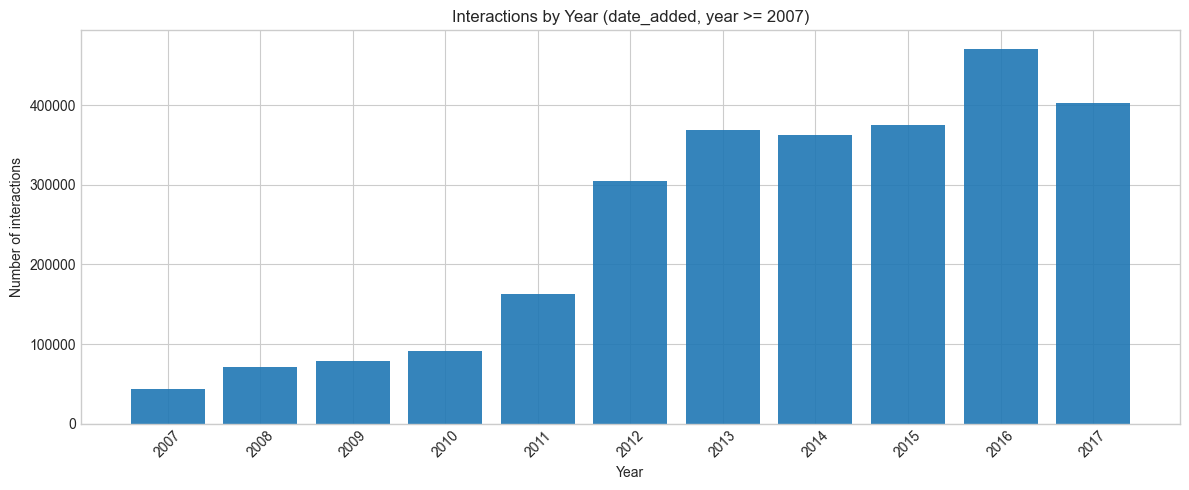

Saved histogram: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\histograms\interactions_by_year_timestamp_selection.png
{'missing_date_added': 0, 'parse_errors': 0, 'duplicate_skipped': 0, 'below_min_year_filtered': 146}


,year,interactions
0,2007,44223
1,2008,71169
2,2009,78881
3,2010,91300
4,2011,163445
5,2012,305325
6,2013,369448
7,2014,362272
8,2015,374946
9,2016,470409


In [12]:
# Histogram interactions by year (after optional min-year filtering)
year_counter = Counter()

year_parse_errors = 0
year_missing_date_added = 0
year_duplicate_skipped = 0
year_below_min_filtered = 0
seen_year_keys = set()

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            continue

        if DEDUP_INTERACTIONS:
            dedup_key = tuple(str(rec.get(k, '')).strip() for k in DEDUP_KEYS)
            if dedup_key in seen_year_keys:
                year_duplicate_skipped += 1
                continue
            seen_year_keys.add(dedup_key)

        date_added = str(rec.get('date_added', '')).strip()
        if not date_added:
            year_missing_date_added += 1
            continue

        dt = pd.to_datetime(date_added, format=DATE_FORMAT, errors='coerce')
        if pd.isna(dt):
            year_parse_errors += 1
            continue

        if APPLY_MIN_YEAR_FILTER and int(dt.year) < MIN_INTERACTION_YEAR:
            year_below_min_filtered += 1
            continue

        year_counter[int(dt.year)] += 1

if len(year_counter) == 0:
    print('Khong co interaction hop le theo date_added de ve histogram.')
else:
    years = sorted(year_counter.keys())
    counts = [year_counter[y] for y in years]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(years, counts, color='#1f77b4', alpha=0.9)
    if APPLY_MIN_YEAR_FILTER:
        ax.set_title(f'Interactions by Year (date_added, year >= {MIN_INTERACTION_YEAR})')
    else:
        ax.set_title('Interactions by Year (date_added)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of interactions')
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()

    hist_year_path = HIST_DIR / 'interactions_by_year_timestamp_selection.png'
    fig.savefig(hist_year_path, dpi=160, bbox_inches='tight')
    plt.show()

    print(f'Saved histogram: {hist_year_path}')
    print({
        'missing_date_added': year_missing_date_added,
        'parse_errors': year_parse_errors,
        'duplicate_skipped': year_duplicate_skipped,
        'below_min_year_filtered': year_below_min_filtered if APPLY_MIN_YEAR_FILTER else 0
    })
    display(pd.DataFrame({'year': years, 'interactions': counts}))

In [13]:
def density_sparsity(n_users, n_items, n_interactions):
    denom = n_users * n_items
    density = (n_interactions / denom) if denom else 0.0
    sparsity = 1.0 - density if denom else 1.0
    return density, sparsity

density_all, sparsity_all = density_sparsity(
    len(unique_users_all),
    len(unique_books_in_interactions),
    interaction_rows_after_dedup
)

density_explicit, sparsity_explicit = density_sparsity(
    len(unique_users_explicit),
    len(unique_books_explicit),
    explicit_interaction_rows
)

density_date_added, sparsity_date_added = density_sparsity(
    len(unique_users_date_added),
    len(unique_books_date_added),
    date_added_interaction_rows
)

sparsity_overview = pd.DataFrame([
    {
        'matrix': 'all_dedup',
        'users': len(unique_users_all),
        'items': len(unique_books_in_interactions),
        'interactions': interaction_rows_after_dedup,
        'density': density_all,
        'sparsity': sparsity_all
    },
    {
        'matrix': 'explicit_dedup',
        'users': len(unique_users_explicit),
        'items': len(unique_books_explicit),
        'interactions': explicit_interaction_rows,
        'density': density_explicit,
        'sparsity': sparsity_explicit
    },
    {
        'matrix': 'date_added_dedup',
        'users': len(unique_users_date_added),
        'items': len(unique_books_date_added),
        'interactions': date_added_interaction_rows,
        'density': density_date_added,
        'sparsity': sparsity_date_added
    }
])

display(sparsity_overview)

,matrix,users,items,interactions,density,sparsity
0,all_dedup,377797,36514,2734204,0.000198,0.999802
1,explicit_dedup,267818,36181,1228992,0.000127,0.999873
2,date_added_dedup,377797,36514,2734204,0.000198,0.999802


## 2A) Sparsity analysis (before thresholding)

Sparsity is computed as: 1 - density, where density = interactions / (users x items).

This helps quantify how sparse the matrix is before and after filtering.

## 2) User activity distribution (critical for threshold selection)

Do not plot rating values here. Plot number of interactions per user.

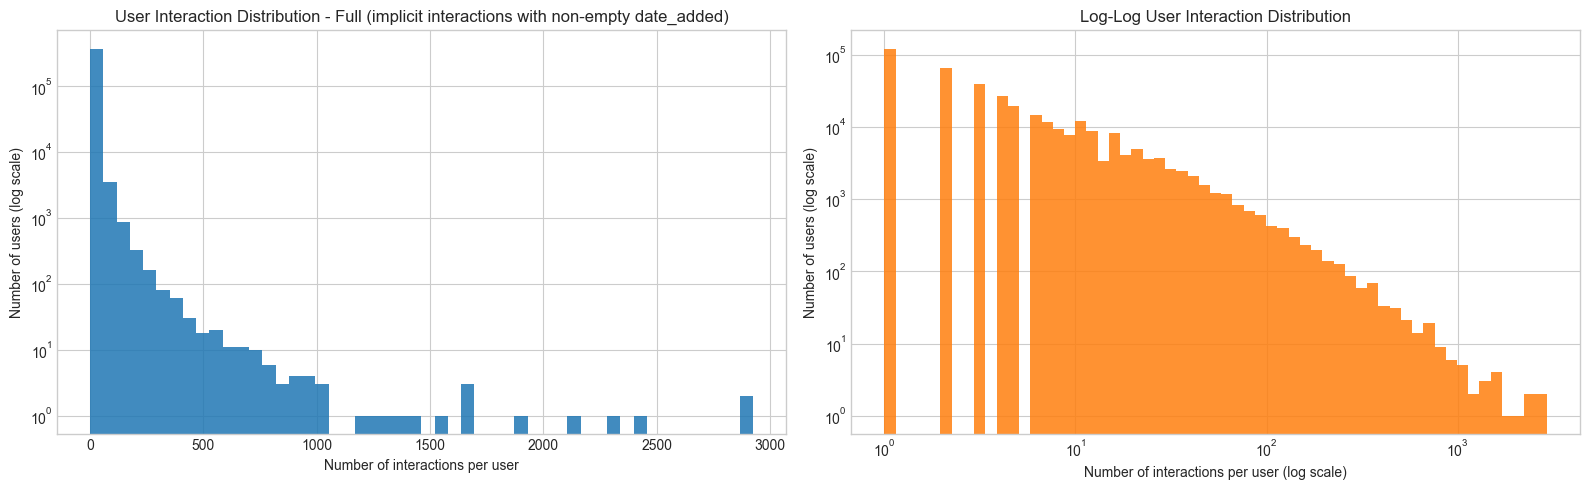

Saved histogram: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\histograms\user_activity_distribution_date_added.png
{'p95_degree': 26, 'p99_degree': 72, 'max_degree': 2924}


In [14]:
mode_tag = THRESHOLD_MODE
p95_degree = int(np.percentile(degrees, 95))
p99_degree = int(np.percentile(degrees, 99))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: full distribution with log-y to reduce domination by low-degree users
axes[0].hist(degrees, bins=50, color='#1f77b4', alpha=0.85, log=True)
axes[0].set_title(f'User Interaction Distribution - Full ({activity_mode_label})')
axes[0].set_xlabel('Number of interactions per user')
axes[0].set_ylabel('Number of users (log scale)')

# Right: log-log with logarithmic bins for long-tail structure
log_bins = np.logspace(np.log10(max(1, degrees.min())), np.log10(degrees.max()), 60)
axes[1].hist(degrees, bins=log_bins, color='#ff7f0e', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Log-Log User Interaction Distribution')
axes[1].set_xlabel('Number of interactions per user (log scale)')
axes[1].set_ylabel('Number of users (log scale)')

plt.tight_layout()
hist_path_1 = HIST_DIR / f'user_activity_distribution_{mode_tag}.png'
fig.savefig(hist_path_1, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved histogram: {hist_path_1}')
print({'p95_degree': p95_degree, 'p99_degree': p99_degree, 'max_degree': int(degrees.max())})

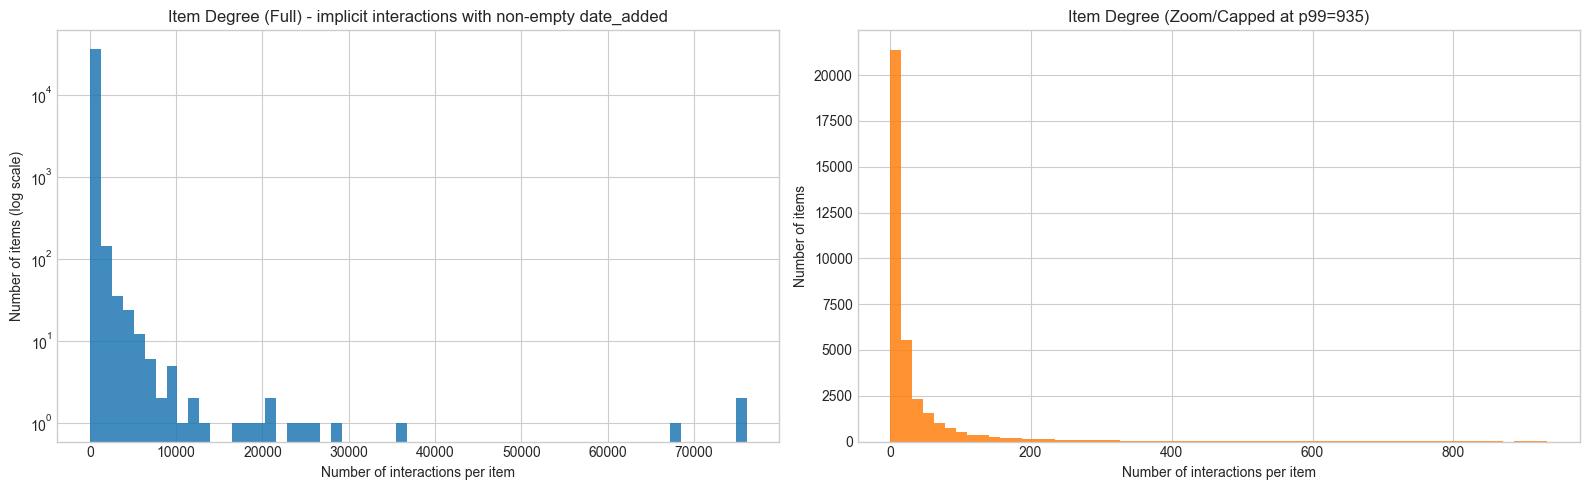

Saved histogram: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\histograms\item_degree_overview_after_cell8_date_added.png
{'item_p95_degree': 213, 'item_p99_degree': 935, 'item_max_degree': 76106, 'avg_interactions_per_item': 74.881}


In [15]:
# Item degree overview before K-filtering (inserted right after Cell 8)
item_degrees = np.array(list(book_degree.values()), dtype=np.int32)

if len(item_degrees) == 0:
    print('No item degrees available to plot.')
else:
    item_p95 = int(np.percentile(item_degrees, 95))
    item_p99 = int(np.percentile(item_degrees, 99))
    item_cap = max(1, item_p99)
    item_degrees_capped = item_degrees[item_degrees <= item_cap]
    if len(item_degrees_capped) == 0:
        item_degrees_capped = item_degrees

    avg_interactions_per_item = float(item_degrees.mean())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Item Degree (Full) with log-scale Y to reveal long tail
    axes[0].hist(item_degrees, bins=60, color='#1f77b4', alpha=0.85, log=True)
    axes[0].set_title(f'Item Degree (Full) - {activity_mode_label}')
    axes[0].set_xlabel('Number of interactions per item')
    axes[0].set_ylabel('Number of items (log scale)')

    # Item Degree (Zoom/Capped) for better visibility of the head
    axes[1].hist(item_degrees_capped, bins=60, color='#ff7f0e', alpha=0.85)
    axes[1].set_title(f'Item Degree (Zoom/Capped at p99={item_cap})')
    axes[1].set_xlabel('Number of interactions per item')
    axes[1].set_ylabel('Number of items')

    plt.tight_layout()
    item_hist_overview_path = HIST_DIR / f'item_degree_overview_after_cell8_{THRESHOLD_MODE}.png'
    fig.savefig(item_hist_overview_path, dpi=160, bbox_inches='tight')
    plt.show()

    print(f'Saved histogram: {item_hist_overview_path}')
    print({
        'item_p95_degree': item_p95,
        'item_p99_degree': item_p99,
        'item_max_degree': int(item_degrees.max()),
        'avg_interactions_per_item': round(avg_interactions_per_item, 4)
    })

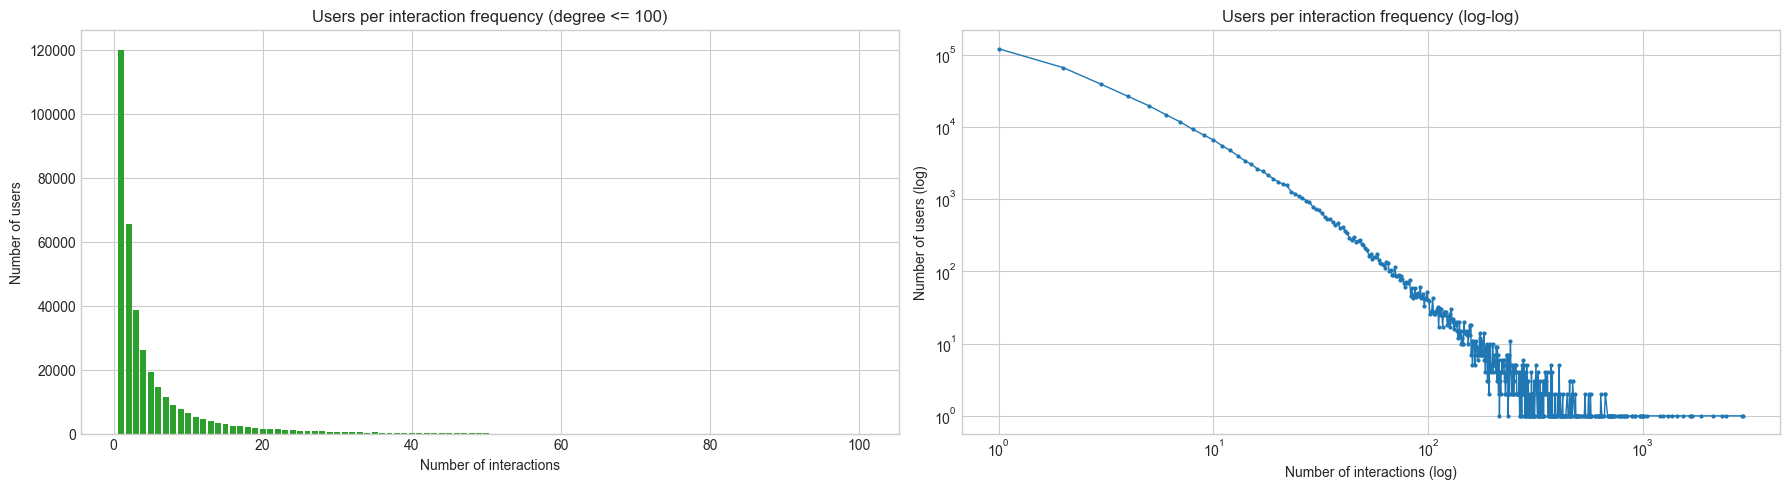

Saved histogram: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\histograms\user_count_per_degree_date_added.png


In [16]:
degree_count = Counter(degrees.tolist())
degree_count_df = pd.DataFrame({
    'degree': list(degree_count.keys()),
    'user_count': list(degree_count.values())
}).sort_values('degree')

# Bar view can be too dense; keep only head region for readability.
max_degree_for_bar = min(100, int(degree_count_df['degree'].max()))
bar_df = degree_count_df[degree_count_df['degree'] <= max_degree_for_bar]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(bar_df['degree'], bar_df['user_count'], color='#2ca02c')
axes[0].set_title(f'Users per interaction frequency (degree <= {max_degree_for_bar})')
axes[0].set_xlabel('Number of interactions')
axes[0].set_ylabel('Number of users')

axes[1].plot(degree_count_df['degree'], degree_count_df['user_count'], marker='o', linewidth=1, markersize=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Users per interaction frequency (log-log)')
axes[1].set_xlabel('Number of interactions (log)')
axes[1].set_ylabel('Number of users (log)')

plt.tight_layout()
hist_path_2 = HIST_DIR / f'user_count_per_degree_{mode_tag}.png'
fig.savefig(hist_path_2, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved histogram: {hist_path_2}')

## 3) Threshold diagnostics: Elbow, Percentile, Coverage

Evaluate several candidate thresholds before selecting min_user_interaction.

In [17]:
candidate_thresholds = [3, 5, 6, 7, 8, 10, 15, 20]

rows = []
total_users = len(degrees)
total_interactions = int(degrees.sum())

# Build threshold-aware item coverage and interactions via second streaming pass.
kept_interactions_by_k = {k: 0 for k in candidate_thresholds}
retained_books_by_k = {k: set() for k in candidate_thresholds}
seen_eval_keys = set()

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            continue

        if DEDUP_INTERACTIONS:
            dedup_key = tuple(str(rec.get(k, '')).strip() for k in DEDUP_KEYS)
            if dedup_key in seen_eval_keys:
                continue
            seen_eval_keys.add(dedup_key)

        raw_rating = rec.get('rating', 0)
        try:
            rating = int(raw_rating)
        except (TypeError, ValueError):
            rating = 0

        if not in_threshold_mode(rec, rating):
            continue

        user_deg = user_degree.get(user_id, 0)
        for k in candidate_thresholds:
            if user_deg >= k:
                kept_interactions_by_k[k] += 1
                retained_books_by_k[k].add(book_id)
            else:
                break

for k in candidate_thresholds:
    kept_users = int((degrees >= k).sum())
    kept_interactions = int(kept_interactions_by_k[k])
    retained_items = len(retained_books_by_k[k])

    dropped_users = total_users - kept_users
    dropped_interactions = total_interactions - kept_interactions

    kept_users_pct = 100.0 * kept_users / total_users if total_users else 0.0
    kept_interactions_pct = 100.0 * kept_interactions / total_interactions if total_interactions else 0.0
    user_drop_rate_pct = 100.0 - kept_users_pct if total_users else 0.0
    interaction_drop_rate_pct = 100.0 - kept_interactions_pct if total_interactions else 0.0

    denom = kept_users * retained_items
    density = (kept_interactions / denom) if denom else 0.0
    sparsity = (1.0 - density) if denom else 1.0

    rows.append({
        'threshold_k': k,
        'remaining_users': kept_users,
        'remaining_users_pct': kept_users_pct,
        'remaining_interactions': kept_interactions,
        'remaining_interactions_pct': kept_interactions_pct,
        'user_drop_count': dropped_users,
        'user_drop_rate_pct': user_drop_rate_pct,
        'interaction_drop_count': dropped_interactions,
        'interaction_drop_rate_pct': interaction_drop_rate_pct,
        'retained_items': retained_items,
        'density': density,
        'sparsity': sparsity,
        'avg_interactions_per_remaining_user': kept_interactions / kept_users if kept_users else 0.0,

        # Keep old column names for backward compatibility with downstream cells.
        'kept_users': kept_users,
        'kept_users_pct': kept_users_pct,
        'kept_interactions': kept_interactions,
        'kept_interactions_pct': kept_interactions_pct,
        'avg_interactions_per_kept_user': kept_interactions / kept_users if kept_users else 0.0
    })

coverage_table = pd.DataFrame(rows)

# Single output table for sensitivity analysis.
sensitivity_table = coverage_table[[
    'threshold_k',
    'remaining_users',
    'remaining_users_pct',
    'remaining_interactions',
    'remaining_interactions_pct',
    'user_drop_rate_pct',
    'interaction_drop_rate_pct',
    'density',
    'sparsity',
    'retained_items',
    'avg_interactions_per_remaining_user'
]].copy()

sensitivity_table

,threshold_k,remaining_users,remaining_users_pct,remaining_interactions,remaining_interactions_pct,user_drop_rate_pct,interaction_drop_rate_pct,density,sparsity,retained_items,avg_interactions_per_remaining_user
0,3,191912,50.797382,2482575,90.792144,49.202618,9.207856,0.000356,0.999644,36326,12.936007
1,5,126699,33.536087,2260514,82.670982,66.463913,17.329018,0.000494,0.999506,36130,17.841609
2,6,107120,28.353701,2162629,79.091155,71.646299,20.908845,0.000560,0.999440,36045,20.188844
3,7,92390,24.454803,2074249,75.858943,75.545197,24.141057,0.000625,0.999375,35945,22.451012
4,8,80696,21.359506,1992384,72.864995,78.640494,27.135005,0.000689,0.999311,35832,24.689997
5,10,63715,16.864788,1848809,67.614204,83.135212,32.385796,0.000814,0.999186,35626,29.016856
6,15,39625,10.488381,1567548,57.327994,89.511619,42.672006,0.001126,0.998874,35134,39.559571
7,20,27487,7.275562,1363978,49.883080,92.724438,50.116920,0.001431,0.998569,34665,49.622658


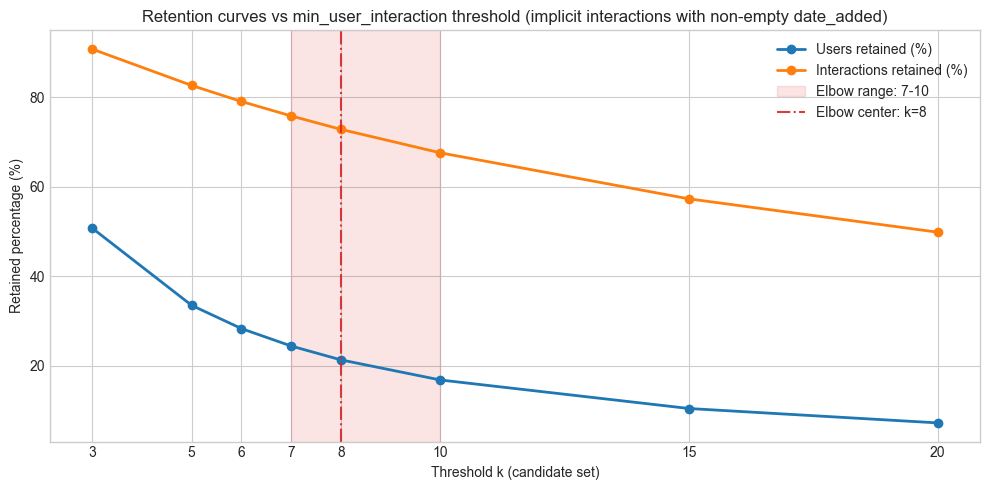

Saved chart: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\histograms\retention_curves_date_added.png
{'elbow_k_center': 8, 'elbow_k_range': (7, 10), 'elbow_candidates': [7, 8, 10]}


,threshold_k,users_retained_pct,interactions_retained_pct,kneedle_distance
0,3,50.797382,90.797557,0.000000
1,5,33.536087,82.676541,0.278965
2,6,28.353701,79.096348,0.339217
3,7,24.454803,75.864136,0.369979
4,8,21.359506,72.870445,0.382276
5,10,16.864788,67.619654,0.367904
6,15,10.488381,57.334065,0.220297
7,20,7.275562,49.887213,0.000000


In [18]:
# Method 1 - Elbow: define a candidate range of k values
k_values = np.array(sorted(candidate_thresholds), dtype=np.int32)
users_retained_pct = []
interactions_retained_pct = []

for k in k_values:
    mask = degrees >= k
    users_retained_pct.append(100.0 * mask.sum() / total_users if total_users else 0.0)
    interactions_retained_pct.append(100.0 * degrees[mask].sum() / total_interactions if total_interactions else 0.0)

# Kneedle-style elbow on user-retention curve
x_span = float(k_values.max() - k_values.min()) if len(k_values) else 0.0
x_norm = (k_values - k_values.min()) / x_span if x_span > 0 else np.zeros(len(k_values))
y_users = np.array(users_retained_pct, dtype=np.float64)
y_span = float(y_users.max() - y_users.min()) if len(y_users) else 0.0
y_norm = (y_users - y_users.min()) / y_span if y_span > 0 else np.zeros(len(y_users))
line = 1 - x_norm
distance = line - y_norm

elbow_idx = int(np.argmax(distance)) if len(distance) else 0
elbow_k_center = int(k_values[elbow_idx]) if len(k_values) else int(candidate_thresholds[0])

# Convert elbow point to elbow range (neighbor window in candidate set)
left_idx = max(0, elbow_idx - 1)
right_idx = min(len(k_values) - 1, elbow_idx + 1)
elbow_candidates = [int(v) for v in k_values[left_idx:right_idx + 1]]
elbow_k_range = (elbow_candidates[0], elbow_candidates[-1])

fig = plt.figure(figsize=(10, 5))
plt.plot(k_values, users_retained_pct, marker='o', label='Users retained (%)', linewidth=2)
plt.plot(k_values, interactions_retained_pct, marker='o', label='Interactions retained (%)', linewidth=2)
plt.axvspan(elbow_k_range[0], elbow_k_range[1], color='#d62728', alpha=0.12, label=f'Elbow range: {elbow_k_range[0]}-{elbow_k_range[1]}')
plt.axvline(x=elbow_k_center, color='#d62728', linestyle='-.', alpha=0.9, label=f'Elbow center: k={elbow_k_center}')
plt.title(f'Retention curves vs min_user_interaction threshold ({activity_mode_label})')
plt.xlabel('Threshold k (candidate set)')
plt.ylabel('Retained percentage (%)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
hist_path_3 = HIST_DIR / f'retention_curves_{mode_tag}.png'
fig.savefig(hist_path_3, dpi=160, bbox_inches='tight')
plt.show()

elbow_table = pd.DataFrame({
    'threshold_k': k_values,
    'users_retained_pct': users_retained_pct,
    'interactions_retained_pct': interactions_retained_pct,
    'kneedle_distance': distance
})

print(f'Saved chart: {hist_path_3}')
print({'elbow_k_center': elbow_k_center, 'elbow_k_range': elbow_k_range, 'elbow_candidates': elbow_candidates})
display(elbow_table)

In [19]:
# Method 2 - Sparsity: remove weak k values inside elbow range
elbow_range_min, elbow_range_max = elbow_k_range
elbow_candidate_set = set(elbow_candidates)

elbow_rows = coverage_table[coverage_table['threshold_k'].isin(elbow_candidate_set)].copy()
if len(elbow_rows) == 0:
    elbow_rows = coverage_table.copy()

# Keep k with better sparsity (drop the worst sparsity quartile)
sparsity_cutoff = float(elbow_rows['sparsity'].quantile(0.75))
sparsity_filtered = elbow_rows[elbow_rows['sparsity'] <= sparsity_cutoff].copy()

if len(sparsity_filtered) == 0:
    # Fallback: keep top density candidates if filter is too strict
    sparsity_filtered = elbow_rows.sort_values(['density', 'threshold_k'], ascending=[False, False]).head(min(2, len(elbow_rows))).copy()

# Method 3 - Trade-off: select final k from sparsity-filtered candidates
tradeoff_table = sparsity_filtered.copy()

def minmax_score(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    span = float(series.max() - series.min())
    if span == 0:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - series.min()) / span

tradeoff_table['interaction_score'] = minmax_score(tradeoff_table['remaining_interactions_pct'])
tradeoff_table['density_score'] = minmax_score(tradeoff_table['density'])
tradeoff_table['user_score'] = minmax_score(tradeoff_table['remaining_users_pct'])

# Weighted trade-off: keep interactions, improve density, avoid dropping too many users
tradeoff_table['tradeoff_score'] = (
    0.50 * tradeoff_table['interaction_score'] +
    0.35 * tradeoff_table['density_score'] +
    0.15 * tradeoff_table['user_score']
)

tradeoff_row = tradeoff_table.sort_values(['tradeoff_score', 'threshold_k'], ascending=[False, False]).iloc[0]
final_threshold_k = int(tradeoff_row['threshold_k'])

sparsity_candidates = sorted(int(k) for k in sparsity_filtered['threshold_k'].tolist())
elbow_range_str = f'[{elbow_range_min}, {elbow_range_max}]'
sparsity_candidates_str = ', '.join(str(k) for k in sparsity_candidates)

threshold_methods = pd.DataFrame([
    {
        'method': 'elbow_range',
        'recommended_k': elbow_range_str,
        'why': 'Kneedle tren retention curve de chon khoang k hop ly'
    },
    {
        'method': 'sparsity_filter',
        'recommended_k': sparsity_candidates_str,
        'why': f'Giu cac k co sparsity <= Q3 trong elbow range (cutoff={sparsity_cutoff:.6f})'
    },
    {
        'method': 'tradeoff_final',
        'recommended_k': final_threshold_k,
        'why': 'Toi uu trade-off giua interaction retention, density va user retention'
    }
])

final_threshold_summary = coverage_table[coverage_table['threshold_k'] == final_threshold_k].copy()
final_threshold_summary['selected_reason'] = '3-step rule: Elbow range -> Sparsity filter -> Trade-off final'

print({'final_threshold_k': final_threshold_k, 'elbow_range': elbow_range_str, 'sparsity_candidates': sparsity_candidates_str})
display(threshold_methods)
display(sparsity_filtered[['threshold_k', 'remaining_users_pct', 'remaining_interactions_pct', 'density', 'sparsity']].sort_values('threshold_k'))
display(tradeoff_table[['threshold_k', 'interaction_score', 'density_score', 'user_score', 'tradeoff_score']].sort_values('threshold_k'))
display(final_threshold_summary)

{'final_threshold_k': 8, 'elbow_range': '[7, 10]', 'sparsity_candidates': '8, 10'}


,method,recommended_k,why
0,elbow_range,"[7, 10]",Kneedle tren retention curve de chon khoang k ...
1,sparsity_filter,"8, 10",Giu cac k co sparsity <= Q3 trong elbow range ...
2,tradeoff_final,8,"Toi uu trade-off giua interaction retention, d..."


,threshold_k,remaining_users_pct,remaining_interactions_pct,density,sparsity
4,8,21.359506,72.864995,0.000689,0.999311
5,10,16.864788,67.614204,0.000814,0.999186


,threshold_k,interaction_score,density_score,user_score,tradeoff_score
4,8,1.0,0.0,1.0,0.65
5,10,0.0,1.0,0.0,0.35


,threshold_k,remaining_users,remaining_users_pct,remaining_interactions,remaining_interactions_pct,user_drop_count,user_drop_rate_pct,interaction_drop_count,interaction_drop_rate_pct,retained_items,density,sparsity,avg_interactions_per_remaining_user,kept_users,kept_users_pct,kept_interactions,kept_interactions_pct,avg_interactions_per_kept_user,selected_reason
4,8,80696,21.359506,1992384,72.864995,297103,78.640494,741966,27.135005,35832,0.000689,0.999311,24.689997,80696,21.359506,1992384,72.864995,24.689997,3-step rule: Elbow range -> Sparsity filter ->...


## 3A) Chon k theo 3 buoc chuan

Quy trinh ap dung:
1. Elbow: xac dinh khoang k hop ly tu retention curve.
2. Sparsity: loai cac k co sparsity xau trong khoang elbow.
3. Trade-off: chon k cuoi cung bang diem can bang giua retention va density.

## 4) Pick threshold and optionally create filtered interactions

Typical candidates after distribution analysis are k=5 or k=10.

In [ ]:
if 'final_threshold_k' not in globals():
    raise RuntimeError('final_threshold_k chua ton tai. Hay chay cell chon k truoc khi filter interactions.')

if 'candidate_thresholds' not in globals() or len(candidate_thresholds) == 0:
    raise RuntimeError('candidate_thresholds chua san sang. Hay chay cell threshold diagnostics truoc.')

SELECTED_MIN_INTERACTION = int(final_threshold_k)
candidate_set = set(int(x) for x in candidate_thresholds)

# Force selected k to belong to candidate set
if SELECTED_MIN_INTERACTION not in candidate_set:
    SELECTED_MIN_INTERACTION = int(min(candidate_set, key=lambda x: abs(x - SELECTED_MIN_INTERACTION)))

# Backward-compatible aliases used by downstream cells
SELECTED_MIN_USER_INTERACTION = SELECTED_MIN_INTERACTION
SELECTED_MIN_ITEM_INTERACTION = SELECTED_MIN_INTERACTION


def iter_mode_edges(with_line=False):
    seen_keys = set()
    with INTERACTIONS_PATH.open('r', encoding='utf-8') as fin:
        for line_no, line in enumerate(fin, start=1):
            if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
                break

            line_stripped = line.strip()
            if not line_stripped:
                continue

            try:
                rec = json.loads(line_stripped)
            except json.JSONDecodeError:
                continue

            user_id = str(rec.get('user_id', '')).strip()
            book_id = str(rec.get('book_id', '')).strip()
            if not user_id or not book_id:
                continue

            if DEDUP_INTERACTIONS:
                dedup_key = tuple(str(rec.get(k, '')).strip() for k in DEDUP_KEYS)
                if dedup_key in seen_keys:
                    continue
                seen_keys.add(dedup_key)

            raw_rating = rec.get('rating', 0)
            try:
                rating = int(raw_rating)
            except (TypeError, ValueError):
                rating = 0

            if not in_threshold_mode(rec, rating):
                continue

            if with_line:
                yield user_id, book_id, line_stripped
            else:
                yield user_id, book_id


removed_users = set()
removed_items = set()
kcore_iteration_log = []

final_user_degree = Counter()
final_item_degree = Counter()
final_edge_count = 0

max_iterations = 100
for it in range(1, max_iterations + 1):
    user_degree_iter = Counter()
    item_degree_iter = Counter()
    edge_count_iter = 0

    for user_id, book_id in iter_mode_edges(with_line=False):
        if user_id in removed_users or book_id in removed_items:
            continue

        user_degree_iter[user_id] += 1
        item_degree_iter[book_id] += 1
        edge_count_iter += 1

    low_users = {u for u, d in user_degree_iter.items() if d < SELECTED_MIN_INTERACTION}
    low_items = {i for i, d in item_degree_iter.items() if d < SELECTED_MIN_INTERACTION}

    kcore_iteration_log.append({
        'iteration': it,
        'active_users': len(user_degree_iter),
        'active_items': len(item_degree_iter),
        'active_interactions': edge_count_iter,
        'low_users_removed_this_iter': len(low_users),
        'low_items_removed_this_iter': len(low_items)
    })

    final_user_degree = user_degree_iter
    final_item_degree = item_degree_iter
    final_edge_count = edge_count_iter

    if len(low_users) == 0 and len(low_items) == 0:
        break

    if edge_count_iter == 0:
        break

    removed_users.update(low_users)
    removed_items.update(low_items)
else:
    raise RuntimeError(f'k-core iterative khong hoi tu sau {max_iterations} vong.')

final_users_set = set(final_user_degree.keys())
final_items_set = set(final_item_degree.keys())

kept_users = len(final_users_set)
kept_items = len(final_items_set)
kept_interactions = int(final_edge_count)
total_users = len(degrees)
total_interactions = int(degrees.sum())

min_user_degree_after = int(min(final_user_degree.values())) if kept_users else 0
min_item_degree_after = int(min(final_item_degree.values())) if kept_items else 0

print({
    'selected_k': SELECTED_MIN_INTERACTION,
    'activity_mode': activity_mode_label,
    'kcore_iterations': len(kcore_iteration_log),
    'kept_users': kept_users,
    'kept_users_pct': round(100 * kept_users / total_users, 2) if total_users else 0.0,
    'kept_items': kept_items,
    'kept_interactions': kept_interactions,
    'kept_interactions_pct': round(100 * kept_interactions / total_interactions, 2) if total_interactions else 0.0,
    'min_user_degree_after_kcore': min_user_degree_after,
    'min_item_degree_after_kcore': min_item_degree_after
})

display(pd.DataFrame(kcore_iteration_log))

if WRITE_FILTERED_FILE:
    mode_suffix = THRESHOLD_MODE
    out_path = DATA_DIR / f'goodreads_interactions_poetry_{mode_suffix}_kcore{SELECTED_MIN_INTERACTION}.json'

    kept_rows = 0
    duplicate_export_skipped = 0
    non_selected_mode_skipped = 0
    not_in_kcore_skipped = 0
    seen_export_keys = set()

    with INTERACTIONS_PATH.open('r', encoding='utf-8') as fin, out_path.open('w', encoding='utf-8') as fout:
        for line_no, line in enumerate(fin, start=1):
            if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
                break

            line_stripped = line.strip()
            if not line_stripped:
                continue

            try:
                rec = json.loads(line_stripped)
            except json.JSONDecodeError:
                continue

            user_id = str(rec.get('user_id', '')).strip()
            book_id = str(rec.get('book_id', '')).strip()
            if not user_id or not book_id:
                continue

            if DEDUP_INTERACTIONS:
                dedup_key = tuple(str(rec.get(k, '')).strip() for k in DEDUP_KEYS)
                if dedup_key in seen_export_keys:
                    duplicate_export_skipped += 1
                    continue
                seen_export_keys.add(dedup_key)

            raw_rating = rec.get('rating', 0)
            try:
                rating = int(raw_rating)
            except (TypeError, ValueError):
                rating = 0

            if not in_threshold_mode(rec, rating):
                non_selected_mode_skipped += 1
                continue

            if user_id in final_users_set and book_id in final_items_set:
                fout.write(line_stripped + '\n')
                kept_rows += 1
            else:
                not_in_kcore_skipped += 1

    print({
        'output_file': str(out_path),
        'kept_rows': kept_rows,
        'duplicate_export_skipped': duplicate_export_skipped,
        'non_selected_mode_skipped': non_selected_mode_skipped,
        'not_in_kcore_skipped': not_in_kcore_skipped
    })
else:
    print('WRITE_FILTERED_FILE=False, skip exporting filtered file.')

## 5) Books metadata EDA (streaming)

Use books file to inspect metadata quality and coverage with interactions.

In [43]:
language_counter = Counter()
publication_years = []
avg_ratings = []
ratings_counts = []
num_pages_list = []

book_rows = 0
book_parse_errors = 0
book_ids_in_metadata = set()

with BOOKS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_BOOK_LINES is not None and line_no > MAX_BOOK_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            book_parse_errors += 1
            continue

        book_rows += 1
        book_id = str(rec.get('book_id', '')).strip()
        if book_id:
            book_ids_in_metadata.add(book_id)

        lang = str(rec.get('language_code', '')).strip() or 'unknown'
        language_counter[lang] += 1

        try:
            y = int(rec.get('publication_year', 0))
            if 1000 <= y <= 2100:
                publication_years.append(y)
        except (TypeError, ValueError):
            pass

        try:
            avg = float(rec.get('average_rating', 0))
            if 0 <= avg <= 5:
                avg_ratings.append(avg)
        except (TypeError, ValueError):
            pass

        try:
            rc = int(rec.get('ratings_count', 0))
            if rc >= 0:
                ratings_counts.append(rc)
        except (TypeError, ValueError):
            pass

        try:
            pages = int(rec.get('num_pages', 0))
            if pages > 0:
                num_pages_list.append(pages)
        except (TypeError, ValueError):
            pass

books_summary = {
    'book_rows': book_rows,
    'book_parse_errors': book_parse_errors,
    'book_ids_in_metadata': len(book_ids_in_metadata),
    'book_ids_in_interactions': len(unique_books_in_interactions),
    'book_id_overlap': len(book_ids_in_metadata.intersection(unique_books_in_interactions))
}
books_summary

{'book_rows': 124082,
 'book_parse_errors': 0,
 'book_ids_in_metadata': 124082,
 'book_ids_in_interactions': 124082,
 'book_id_overlap': 124082}

,book_count
unknown,72496
eng,30253
en-US,6197
en-GB,2071
spa,1501
ind,1147
ger,1043
fin,975
ita,903
nl,837


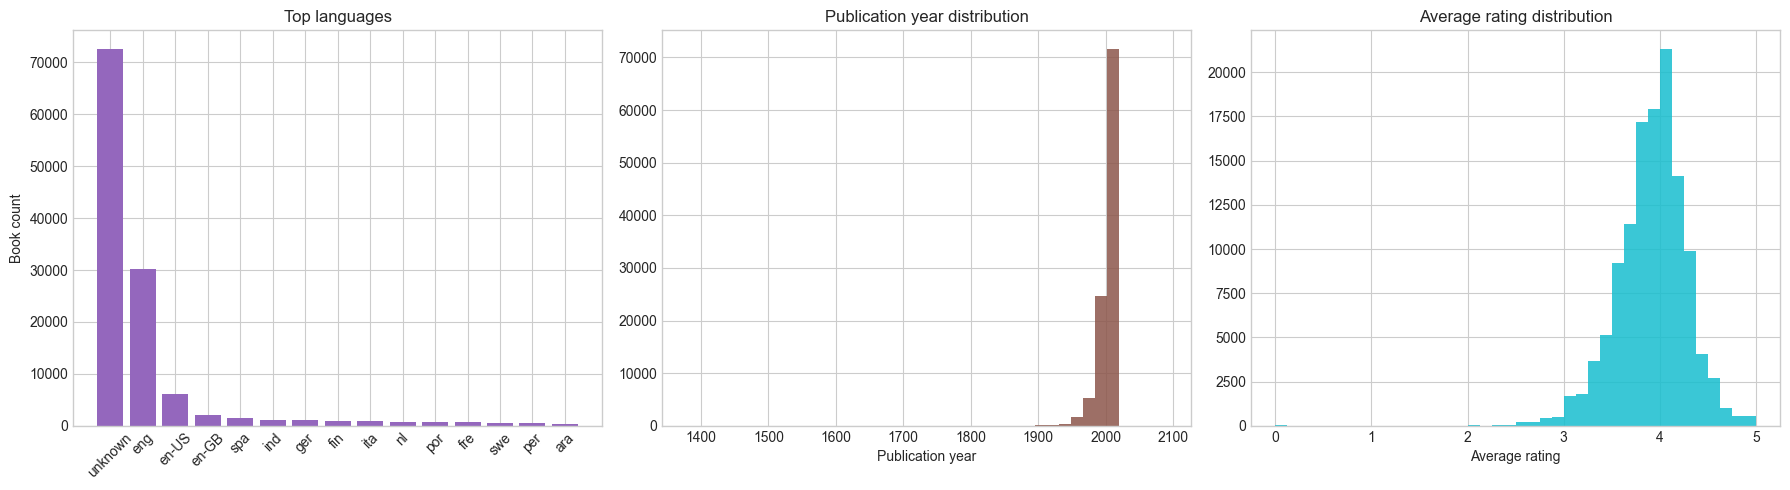

Saved histogram: eda_outputs\histograms\books_metadata_histograms.png


In [44]:
top_languages = pd.Series(language_counter).sort_values(ascending=False).head(15)
display(top_languages.to_frame('book_count'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(top_languages.index, top_languages.values, color='#9467bd')
axes[0].set_title('Top languages')
axes[0].set_ylabel('Book count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(publication_years, bins=40, color='#8c564b', alpha=0.85)
axes[1].set_title('Publication year distribution')
axes[1].set_xlabel('Publication year')

axes[2].hist(avg_ratings, bins=40, color='#17becf', alpha=0.85)
axes[2].set_title('Average rating distribution')
axes[2].set_xlabel('Average rating')

plt.tight_layout()
hist_path_4 = HIST_DIR / 'books_metadata_histograms.png'
fig.savefig(hist_path_4, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved histogram: {hist_path_4}')

In [ ]:
# Threshold decision for user and item
item_degrees = np.array(list(book_degree.values()), dtype=np.int32)
min_user_interaction = int(final_threshold_k) if 'final_threshold_k' in globals() else int(SELECTED_MIN_USER_INTERACTION)

item_k_candidates = [3, 5, 8, 10]

# Method A: item elbow
item_k_values = np.arange(1, 21)
items_retained_pct = [100.0 * (item_degrees >= k).sum() / len(item_degrees) for k in item_k_values]
x_item = (item_k_values - item_k_values.min()) / (item_k_values.max() - item_k_values.min())
y_item = np.array(items_retained_pct)
y_item_norm = (y_item - y_item.min()) / (y_item.max() - y_item.min())
item_line = 1 - x_item
item_distance = item_line - y_item_norm
item_elbow_raw = int(item_k_values[np.argmax(item_distance)])
item_method_elbow = int(min(item_k_candidates, key=lambda x: abs(x - item_elbow_raw)))

# Method B: item percentile
item_percentile_target = 75
item_percentile_raw = int(np.ceil(np.percentile(item_degrees, item_percentile_target)))
item_method_percentile = int(min(item_k_candidates, key=lambda x: abs(x - item_percentile_raw)))

# Method C: coverage-density with fixed min_user_interaction
item_edges_by_k = {k: 0 for k in item_k_candidates}
item_users_by_k = {k: set() for k in item_k_candidates}
item_items_by_k = {k: set() for k in item_k_candidates}

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            continue

        raw_rating = rec.get('rating', 0)
        try:
            rating = int(raw_rating)
        except (TypeError, ValueError):
            rating = 0

        if not in_threshold_mode(rec, rating):
            continue

        if user_degree.get(user_id, 0) < min_user_interaction:
            continue

        item_deg = book_degree.get(book_id, 0)
        for k in item_k_candidates:
            if item_deg >= k:
                item_edges_by_k[k] += 1
                item_users_by_k[k].add(user_id)
                item_items_by_k[k].add(book_id)
            else:
                break

item_rows = []
max_edges_item = max(item_edges_by_k.values()) if len(item_edges_by_k) else 0
for k in item_k_candidates:
    n_users_k = len(item_users_by_k[k])
    n_items_k = len(item_items_by_k[k])
    n_edges_k = int(item_edges_by_k[k])
    denom = n_users_k * n_items_k
    density_k = (n_edges_k / denom) if denom else 0.0
    item_rows.append({
        'item_k': k,
        'kept_users': n_users_k,
        'kept_items': n_items_k,
        'kept_interactions': n_edges_k,
        'kept_interactions_pct': (100.0 * n_edges_k / max_edges_item) if max_edges_item else 0.0,
        'density': density_k
    })

item_threshold_table = pd.DataFrame(item_rows)
coverage_item_candidates = item_threshold_table[item_threshold_table['kept_interactions_pct'] >= 80.0]
if len(coverage_item_candidates) > 0:
    item_method_coverage = int(coverage_item_candidates.sort_values(['density', 'item_k'], ascending=[False, False]).iloc[0]['item_k'])
else:
    item_method_coverage = int(item_threshold_table.sort_values(['kept_interactions', 'density'], ascending=[False, False]).iloc[0]['item_k'])

item_votes = [item_method_elbow, item_method_percentile, item_method_coverage]
min_item_interaction = int(np.median(item_votes))
min_item_interaction = int(min(item_k_candidates, key=lambda x: abs(x - min_item_interaction)))

threshold_methods_item = pd.DataFrame([
    {'method': 'item_elbow', 'recommended_k': item_method_elbow},
    {'method': f'item_percentile_{item_percentile_target}', 'recommended_k': item_method_percentile},
    {'method': 'item_coverage_density', 'recommended_k': item_method_coverage},
    {'method': 'item_final_median_vote', 'recommended_k': min_item_interaction}
])

hyperparams_table = pd.DataFrame([
    {'hyperparameter': 'min_user_interaction', 'value': min_user_interaction, 'reason': 'consensus of user elbow + percentile + coverage-density methods'},
    {'hyperparameter': 'min_item_interaction', 'value': min_item_interaction, 'reason': 'consensus of item elbow + percentile + coverage-density methods'},
    {'hyperparameter': 'k_core', 'value': min_user_interaction, 'reason': 'k-profile shows strong density gain while graph remains large enough'}
])

display(item_threshold_table)
display(threshold_methods_item)
display(hyperparams_table)

,item_k,kept_users,kept_items,kept_interactions,kept_interactions_pct,density
0,3,120853,90712,5337148,100.000000,0.000487
1,5,120852,71105,5276006,98.854407,0.000614
2,8,120851,53501,5182814,97.108306,0.000802
3,10,120849,45999,5125734,96.038821,0.000922


,method,recommended_k
0,item_elbow,8
1,item_percentile_75,10
2,item_coverage_density,10
3,item_final_median_vote,10


,hyperparameter,value,reason
0,min_user_interaction,10,consensus of user elbow + percentile + coverag...
1,min_item_interaction,10,consensus of item elbow + percentile + coverag...
2,k_core,10,k-profile shows strong density gain while grap...


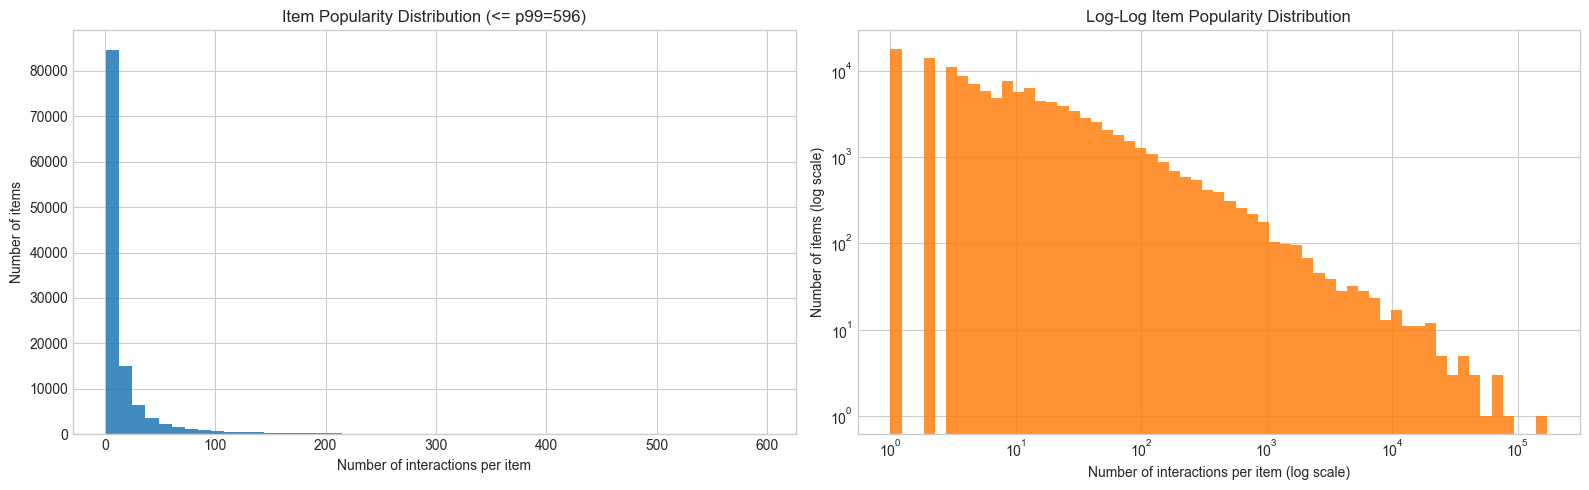

Saved histogram: eda_outputs\histograms\item_popularity_distribution_explicit.png


,insight,value
0,users_with_lt5_interactions_ratio,0.57458
1,items_with_lt5_interactions_ratio,0.42021
2,user_long_tail_exists,True
3,item_long_tail_exists,True


In [60]:
# Item popularity distribution (histogram + log-log)
item_degrees = np.array(list(book_degree.values()), dtype=np.int32)
item_p99 = int(np.percentile(item_degrees, 99))
item_degrees_capped = item_degrees[item_degrees <= item_p99]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(item_degrees_capped, bins=50, color='#1f77b4', alpha=0.85)
axes[0].set_title(f'Item Popularity Distribution (<= p99={item_p99})')
axes[0].set_xlabel('Number of interactions per item')
axes[0].set_ylabel('Number of items')

item_log_bins = np.logspace(np.log10(max(1, item_degrees.min())), np.log10(item_degrees.max()), 60)
axes[1].hist(item_degrees, bins=item_log_bins, color='#ff7f0e', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Log-Log Item Popularity Distribution')
axes[1].set_xlabel('Number of interactions per item (log scale)')
axes[1].set_ylabel('Number of items (log scale)')

plt.tight_layout()
hist_path_item = HIST_DIR / f'item_popularity_distribution_{mode_tag}.png'
fig.savefig(hist_path_item, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved histogram: {hist_path_item}')

user_lt5_ratio = float((degrees < 5).mean()) if len(degrees) else 0.0
item_lt5_ratio = float((item_degrees < 5).mean()) if len(item_degrees) else 0.0
distribution_insights = pd.DataFrame([
    {'insight': 'users_with_lt5_interactions_ratio', 'value': user_lt5_ratio},
    {'insight': 'items_with_lt5_interactions_ratio', 'value': item_lt5_ratio},
    {'insight': 'user_long_tail_exists', 'value': bool(np.percentile(degrees, 99) > 10)},
    {'insight': 'item_long_tail_exists', 'value': bool(np.percentile(item_degrees, 99) > 10)}
])
display(distribution_insights)

In [ ]:
# Final model-ready EDA outputs
if THRESHOLD_MODE == 'date_added':
    base_users = len(unique_users_date_added)
    base_items = len(unique_books_date_added)
    base_interactions = date_added_interaction_rows
elif THRESHOLD_MODE == 'explicit':
    base_users = len(unique_users_explicit)
    base_items = len(unique_books_explicit)
    base_interactions = explicit_interaction_rows
else:
    base_users = len(unique_users_all)
    base_items = len(unique_books_in_interactions)
    base_interactions = interaction_rows_after_dedup

base_density, base_sparsity = density_sparsity(base_users, base_items, base_interactions)

filtered_user_set = set()
filtered_item_set = set()
filtered_user_degree = Counter()
filtered_item_degree = Counter()
filtered_edges = 0

parent = {}
size = {}

def uf_add(node):
    if node not in parent:
        parent[node] = node
        size[node] = 1

def uf_find(node):
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node

def uf_union(a, b):
    root_a = uf_find(a)
    root_b = uf_find(b)
    if root_a == root_b:
        return
    if size[root_a] < size[root_b]:
        root_a, root_b = root_b, root_a
    parent[root_b] = root_a
    size[root_a] += size[root_b]

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            continue

        raw_rating = rec.get('rating', 0)
        try:
            rating = int(raw_rating)
        except (TypeError, ValueError):
            rating = 0

        if not in_threshold_mode(rec, rating):
            continue

        if user_degree.get(user_id, 0) < min_user_interaction:
            continue
        if book_degree.get(book_id, 0) < min_item_interaction:
            continue

        filtered_edges += 1
        filtered_user_set.add(user_id)
        filtered_item_set.add(book_id)
        filtered_user_degree[user_id] += 1
        filtered_item_degree[book_id] += 1

        user_node = f'u:{user_id}'
        item_node = f'i:{book_id}'
        uf_add(user_node)
        uf_add(item_node)
        uf_union(user_node, item_node)

filtered_users = len(filtered_user_set)
filtered_items = len(filtered_item_set)
filtered_density, filtered_sparsity = density_sparsity(filtered_users, filtered_items, filtered_edges)

dataset_summary_table = pd.DataFrame([
    {'stage': 'before_filtering', 'users': base_users, 'items': base_items, 'interactions': base_interactions, 'density': base_density},
    {'stage': 'after_filtering', 'users': filtered_users, 'items': filtered_items, 'interactions': filtered_edges, 'density': filtered_density}
])

filtering_results_table = pd.DataFrame([
    {'metric': 'Users', 'Before': base_users, 'After': filtered_users},
    {'metric': 'Items', 'Before': base_items, 'After': filtered_items},
    {'metric': 'Interactions', 'Before': base_interactions, 'After': filtered_edges},
    {'metric': 'Density', 'Before': base_density, 'After': filtered_density}
])

component_counter = Counter()
for node in parent.keys():
    component_counter[uf_find(node)] += 1

num_components = len(component_counter)
largest_component_size = max(component_counter.values()) if num_components else 0
avg_degree = (2.0 * filtered_edges / (filtered_users + filtered_items)) if (filtered_users + filtered_items) else 0.0

graph_properties_table = pd.DataFrame([
    {'property': 'connected_components', 'value': num_components},
    {'property': 'largest_component_size', 'value': largest_component_size},
    {'property': 'average_degree', 'value': avg_degree}
])

before_cold_user_ratio = float((degrees < min_user_interaction).mean()) if len(degrees) else 0.0
before_cold_item_ratio = float((item_degrees < min_item_interaction).mean()) if len(item_degrees) else 0.0
after_user_degrees = np.array(list(filtered_user_degree.values()), dtype=np.int32) if filtered_users else np.array([])
after_item_degrees = np.array(list(filtered_item_degree.values()), dtype=np.int32) if filtered_items else np.array([])
after_cold_user_ratio = float((after_user_degrees < min_user_interaction).mean()) if len(after_user_degrees) else 0.0
after_cold_item_ratio = float((after_item_degrees < min_item_interaction).mean()) if len(after_item_degrees) else 0.0

learnability_table = pd.DataFrame([
    {'metric': 'sparsity', 'before': base_sparsity, 'after': filtered_sparsity},
    {'metric': 'cold_start_user_ratio', 'before': before_cold_user_ratio, 'after': after_cold_user_ratio},
    {'metric': 'cold_start_item_ratio', 'before': before_cold_item_ratio, 'after': after_cold_item_ratio}
])

kcore_table = coverage_table[['threshold_k', 'kept_users', 'retained_items', 'kept_interactions', 'density']].copy()
kcore_table['nodes'] = kcore_table['kept_users'] + kcore_table['retained_items']
kcore_table = kcore_table[['threshold_k', 'nodes', 'kept_interactions', 'density']]
kcore_table.columns = ['k', 'nodes', 'edges', 'density']
optimal_k_core = int(min_user_interaction)

final_output_table = pd.DataFrame([
    {'output': 'Filtered Users', 'value': filtered_users},
    {'output': 'Filtered Items', 'value': filtered_items},
    {'output': 'Filtered Interactions', 'value': filtered_edges},
    {'output': 'Filtered Density', 'value': filtered_density},
    {'output': 'min_user_interaction', 'value': min_user_interaction},
    {'output': 'min_item_interaction', 'value': min_item_interaction},
    {'output': 'k_core', 'value': optimal_k_core}
])

print({'optimal_k_core': optimal_k_core})
display(dataset_summary_table)
display(filtering_results_table)
display(kcore_table)
display(graph_properties_table)
display(learnability_table)
display(final_output_table)

{'optimal_k_core': 10}


,stage,users,items,interactions,density
0,before_filtering,462164,122741,6384470,0.000113
1,after_filtering,120849,45999,5125734,0.000922


,metric,Before,After
0,Users,4.621640e+05,1.208490e+05
1,Items,1.227410e+05,4.599900e+04
2,Interactions,6.384470e+06,5.125734e+06
3,Density,1.125483e-04,9.220715e-04


,k,nodes,edges,density
0,3,390853,6124533,0.000186
1,5,318407,5878879,0.000246
2,10,241441,5378424,0.000369
3,15,205849,4973204,0.000482
4,20,184232,4629128,0.000593
5,30,158750,4074818,0.000822
6,40,144395,3662936,0.001050
7,50,135095,3337834,0.001281


,property,value
0,connected_components,1.000000
1,largest_component_size,166848.000000
2,average_degree,61.441959


,metric,before,after
0,sparsity,0.999887,0.999078
1,cold_start_user_ratio,0.738506,0.021481
2,cold_start_item_ratio,0.625162,0.071132


,output,value
0,Filtered Users,1.208490e+05
1,Filtered Items,4.599900e+04
2,Filtered Interactions,5.125734e+06
3,Filtered Density,9.220715e-04
4,min_user_interaction,1.000000e+01
5,min_item_interaction,1.000000e+01
6,k_core,1.000000e+01


## 7) Final EDA Output for Modeling (GLRS)

Required outputs in this section:
- Dataset summary
- Threshold decisions
- Before/after filtering metrics
- k-core profile
- Graph properties and learnability

## 8) Report-ready interpretation template

Use this structure in your report:

1. User activity distribution is heavily long-tail; many users have very low interactions (often 1-3).
2. Low-activity users increase sparsity and add noise for collaborative filtering.
3. Threshold k=3 is usually too permissive; evaluate k=5 and k=10 using coverage table.
4. Final threshold is selected from distribution evidence (histogram + log-log + retention curves), not arbitrarily.

Important insight: k-core filtering is a consequence; user activity distribution is the root cause.

In [62]:
# 9) Export final EDA outputs to CSV files
from datetime import datetime

DATASET_SUMMARY_CSV_PATH = OUTPUT_DIR / 'eda_dataset_summary.csv'
FILTERING_RESULTS_CSV_PATH = OUTPUT_DIR / 'eda_filtering_results.csv'
KCORE_CSV_PATH = OUTPUT_DIR / 'eda_kcore_profile.csv'
GRAPH_PROPERTIES_CSV_PATH = OUTPUT_DIR / 'eda_graph_properties.csv'
LEARNABILITY_CSV_PATH = OUTPUT_DIR / 'eda_learnability.csv'
HYPERPARAMS_CSV_PATH = OUTPUT_DIR / 'eda_hyperparameters.csv'
DISTRIBUTION_INSIGHTS_CSV_PATH = OUTPUT_DIR / 'eda_distribution_insights.csv'
ITEM_THRESHOLD_CSV_PATH = OUTPUT_DIR / 'eda_item_threshold_table.csv'
FINAL_OUTPUT_CSV_PATH = OUTPUT_DIR / 'eda_final_output.csv'

METHODS_CSV_PATH = OUTPUT_DIR / 'eda_threshold_methods.csv'
SPARSITY_CSV_PATH = OUTPUT_DIR / 'eda_sparsity_overview.csv'
FINAL_THRESHOLD_CSV_PATH = OUTPUT_DIR / 'eda_final_threshold_summary.csv'
REPORT_CSV_PATH = OUTPUT_DIR / 'eda_report_summary.csv'
COVERAGE_CSV_PATH = OUTPUT_DIR / 'eda_coverage_table.csv'
PERCENTILE_CSV_PATH = OUTPUT_DIR / 'eda_percentile_table.csv'

def safe_to_csv(df, path):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        return path
    except PermissionError:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        fallback = path.with_name(f"{path.stem}_{ts}{path.suffix}")
        df.to_csv(fallback, index=False, encoding='utf-8-sig')
        return fallback

saved_dataset_summary = safe_to_csv(dataset_summary_table, DATASET_SUMMARY_CSV_PATH)
saved_filtering_results = safe_to_csv(filtering_results_table, FILTERING_RESULTS_CSV_PATH)
saved_kcore = safe_to_csv(kcore_table, KCORE_CSV_PATH)
saved_graph_props = safe_to_csv(graph_properties_table, GRAPH_PROPERTIES_CSV_PATH)
saved_learnability = safe_to_csv(learnability_table, LEARNABILITY_CSV_PATH)
saved_hyperparams = safe_to_csv(hyperparams_table, HYPERPARAMS_CSV_PATH)
saved_dist_insights = safe_to_csv(distribution_insights, DISTRIBUTION_INSIGHTS_CSV_PATH)
saved_item_threshold = safe_to_csv(item_threshold_table, ITEM_THRESHOLD_CSV_PATH)
saved_final_output = safe_to_csv(final_output_table, FINAL_OUTPUT_CSV_PATH)

saved_report = safe_to_csv(pd.DataFrame([
    {'section': 'final_decision', 'metric': 'min_user_interaction', 'value': min_user_interaction},
    {'section': 'final_decision', 'metric': 'min_item_interaction', 'value': min_item_interaction},
    {'section': 'final_decision', 'metric': 'k_core', 'value': optimal_k_core},
    {'section': 'final_decision', 'metric': 'filtered_users', 'value': int(filtered_users)},
    {'section': 'final_decision', 'metric': 'filtered_items', 'value': int(filtered_items)},
    {'section': 'final_decision', 'metric': 'filtered_interactions', 'value': int(filtered_edges)},
    {'section': 'final_decision', 'metric': 'filtered_density', 'value': float(filtered_density)}
]), REPORT_CSV_PATH)

saved_coverage = safe_to_csv(coverage_table, COVERAGE_CSV_PATH)
saved_percentile = safe_to_csv(percentile_table, PERCENTILE_CSV_PATH)
saved_methods = safe_to_csv(threshold_methods, METHODS_CSV_PATH)
saved_sparsity = safe_to_csv(sparsity_overview, SPARSITY_CSV_PATH)
saved_final_threshold = safe_to_csv(final_threshold_summary, FINAL_THRESHOLD_CSV_PATH)

print(f'Saved dataset summary CSV: {saved_dataset_summary}')
print(f'Saved filtering results CSV: {saved_filtering_results}')
print(f'Saved k-core profile CSV: {saved_kcore}')
print(f'Saved graph properties CSV: {saved_graph_props}')
print(f'Saved learnability CSV: {saved_learnability}')
print(f'Saved hyperparameters CSV: {saved_hyperparams}')
print(f'Saved distribution insights CSV: {saved_dist_insights}')
print(f'Saved item-threshold CSV: {saved_item_threshold}')
print(f'Saved final output CSV: {saved_final_output}')
print(f'Saved compact report CSV: {saved_report}')
print(f'Saved coverage CSV: {saved_coverage}')
print(f'Saved percentile CSV: {saved_percentile}')
print(f'Saved threshold-method CSV: {saved_methods}')
print(f'Saved sparsity CSV: {saved_sparsity}')
print(f'Saved final-threshold CSV: {saved_final_threshold}')

display(final_output_table)
display(hyperparams_table)

Saved dataset summary CSV: eda_outputs\eda_dataset_summary.csv
Saved filtering results CSV: eda_outputs\eda_filtering_results.csv
Saved k-core profile CSV: eda_outputs\eda_kcore_profile.csv
Saved graph properties CSV: eda_outputs\eda_graph_properties.csv
Saved learnability CSV: eda_outputs\eda_learnability.csv
Saved hyperparameters CSV: eda_outputs\eda_hyperparameters.csv
Saved distribution insights CSV: eda_outputs\eda_distribution_insights.csv
Saved item-threshold CSV: eda_outputs\eda_item_threshold_table.csv
Saved final output CSV: eda_outputs\eda_final_output.csv
Saved compact report CSV: eda_outputs\eda_report_summary.csv
Saved coverage CSV: eda_outputs\eda_coverage_table.csv
Saved percentile CSV: eda_outputs\eda_percentile_table.csv
Saved threshold-method CSV: eda_outputs\eda_threshold_methods.csv
Saved sparsity CSV: eda_outputs\eda_sparsity_overview.csv
Saved final-threshold CSV: eda_outputs\eda_final_threshold_summary.csv


,output,value
0,Filtered Users,1.208490e+05
1,Filtered Items,4.599900e+04
2,Filtered Interactions,5.125734e+06
3,Filtered Density,9.220715e-04
4,min_user_interaction,1.000000e+01
5,min_item_interaction,1.000000e+01
6,k_core,1.000000e+01


,hyperparameter,value,reason
0,min_user_interaction,10,consensus of user elbow + percentile + coverag...
1,min_item_interaction,10,consensus of item elbow + percentile + coverag...
2,k_core,10,k-profile shows strong density gain while grap...
